In [1]:
import sys, os
from pathlib import Path

# Make imports robust to notebook working directory.
# This notebook lives in .../DDDF/src, so we add both src and repo root.
nb_dir = Path.cwd()
if not (nb_dir / 'config.py').exists() and (nb_dir / 'src' / 'config.py').exists():
    nb_dir = nb_dir / 'src'
repo_root = nb_dir.parent

for p in (str(nb_dir), str(repo_root)):
    if p not in sys.path:
        sys.path.insert(0, p)

import dddf

import config as cfg
import numpy as np
from pipeline import (load_snapshot_pair, compute_target_psi_div, compute_best_fit)

# ── User settings ─────────────────────────────────────────────────
N_p        = cfg.N_p
data_dir   = cfg.data_dir
n_realizations = 20
# ──────────────────────────────────────────────────────────────────

# ── Derived constants ──────────────────────────────────────────────
L         = cfg.L
boxsize   = cfg.boxsize
MAS       = cfg.MAS
threads   = cfg.threads
grid_size = N_p

dl        = dddf.DDDF(cfg.init_redshift(N_p), cfg.final_snapshot_z, cfg.Omega_m, threads)
veck_main = dl.Veck(dl, N_p, boxsize, padding=0)

print(f'hostname: {os.popen("hostname").read().strip()}')
print(f'N_p={N_p}, boxsize={boxsize}, data_dir={data_dir}')

KeyboardInterrupt: 

## Generate Averaged Best-fit Coef

In [ ]:
# ── Section settings ──────────────────────────────────────────────
overwrite   = True
# ──────────────────────────────────────────────────────────────────

for realization in range(n_realizations):
    coef_file   = cfg.best_fit_coef_path(realization, data_dir, cfg.L, N_p)  # None -> refit from scratch
    snapshot_info = load_snapshot_pair(
        dl,
        cfg.snapshot_paths(realization, N_p),
        cfg.snapshot_format(N_p),
        boxsize, grid_size,
    )

    init_delta     = snapshot_info[0]['delta']
    target_psi_div = compute_target_psi_div(dl, snapshot_info, N_p, boxsize, veck_main)

    best_fit_psi_div, best_fit_delta, target_delta = compute_best_fit(
        dl, init_delta, target_psi_div,
        snapshot_info[0]['pos'], snapshot_info[1]['delta'],
        veck_main, N_p, boxsize, MAS,
        realization, data_dir, L,
        coef_file=coef_file,
        overwrite=overwrite,
    )

Reading snapshot...
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Computing sec order displacement...
  layer 0
  coef = [-1.0440170e-04  5.2577639e-01 -4.2584985e+06  3.8218029e-02
 -7.6211272e-03 -5.4875400e-02 -8.7227577e-01  2.3198076e+02
 -4.0987266e+03  6.7229604e+03 -2.8542925e+03]
Saved best-fit psi_div to /pscratch/sd/l/liuyh15/DDDF/data/tophat0.4shifted/best-fitL1N256-0.npz
Assigning displacements to particles using CIC...
Reading snapshot...
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Computing sec order displacement...
  layer 0
  coef = [-7.70414681e-06  5.30698061e-01 -3.95754531e+05  1.09976055e-02
 -8.94739851e-03 -4.62390035e-02 -2.12025428e+00  5.11166199e+02
 -8.30030273e+03 -8.66312073e+02  8.65861133e+03]
Saved best-fit psi_div to /pscratch/sd/l/liuyh15/DDDF/data/tophat0.4shifted/best-fitL1N256-1.npz
Assigning displacements to particles using CIC...
Reading snapshot...
Reading snapsho

In [ ]:
# ── Average best-fit coefficients across realizations ─────────────
coef_list = []
for r in range(n_realizations):
    p = cfg.best_fit_coef_path(r, data_dir, cfg.L, N_p)
    coef_list.append(np.load(p)['layer_best_fit_coef_all'])

avg_coef = np.mean(coef_list, axis=0)

avg_coef_path = cfg.best_fit_avg_coef_path(data_dir, cfg.L, N_p)
np.savez(avg_coef_path, layer_best_fit_coef_all=avg_coef)
print(f'Saved averaged coefficients ({n_realizations} realizations) to {avg_coef_path}')
print(f'shape: {avg_coef.shape}')
print(f'avg_coef:\n{avg_coef}')


Saved averaged coefficients (20 realizations) to /pscratch/sd/l/liuyh15/DDDF/data/tophat0.4shifted/best-fit-coef-avgL1N256.npz
shape: (1, 11)
avg_coef:
[[ 2.2500759e-05  5.3080595e-01 -2.9252005e+06  3.4810085e-02
  -9.8778466e-03 -5.3419173e-02 -9.3962401e-01  2.4392313e+02
  -4.0726809e+03  2.6027405e+03  1.2280052e+03]]


## Best-fit with Averaged Coef: Power Spectra

Reading snapshot...
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Computing sec order displacement...
  layer 0
  coef = [ 2.2500759e-05  5.3080595e-01 -2.9252005e+06  3.4810085e-02
 -9.8778466e-03 -5.3419173e-02 -9.3962401e-01  2.4392313e+02
 -4.0726809e+03  2.6027405e+03  1.2280052e+03]
Saved best-fit psi_div to /pscratch/sd/l/liuyh15/DDDF/data/tophat0.4shifted/best-fitL1N256-0.npz
Assigning displacements to particles using CIC...
Reading snapshot...
Reading snapshot...
Computing displacement field using CIC...
Computing divergence...
Computing sec order displacement...
  layer 0
  coef = [ 2.2500759e-05  5.3080595e-01 -2.9252005e+06  3.4810085e-02
 -9.8778466e-03 -5.3419173e-02 -9.3962401e-01  2.4392313e+02
 -4.0726809e+03  2.6027405e+03  1.2280052e+03]
Saved best-fit psi_div to /pscratch/sd/l/liuyh15/DDDF/data/tophat0.4shifted/best-fitL1N256-1.npz
Assigning displacements to particles using CIC...
Reading snapshot...
Reading snapshot...
Comput

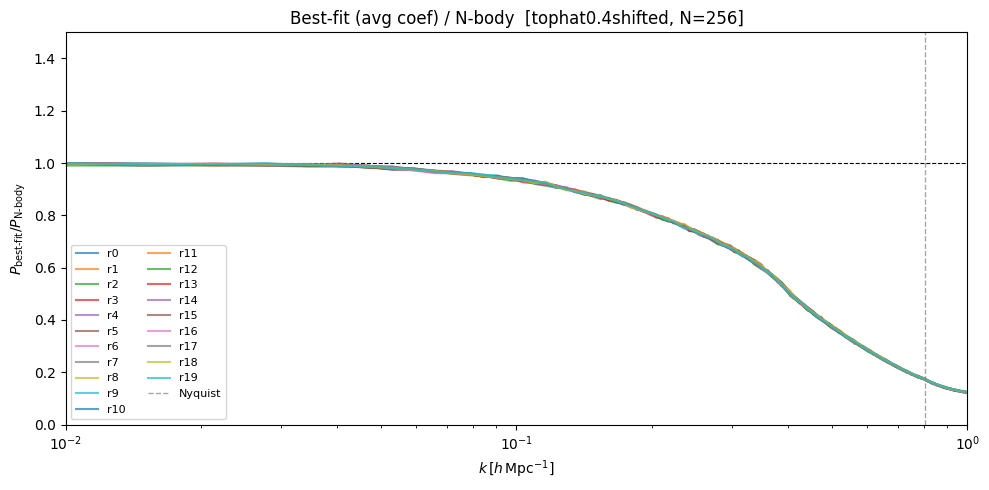

In [ ]:
import Pk_library as PKL
import matplotlib.pyplot as plt

avg_coef_path = cfg.best_fit_avg_coef_path(data_dir, cfg.L, N_p)
overwrite = True

fig, ax = plt.subplots(figsize=(10, 5))
ax.set_xscale('log')
ax.set_xlabel(r'$k\,[h\,{\rm Mpc}^{-1}]$')
ax.set_ylabel(r'$P_{\rm best\text{-}fit} / P_{\rm N\text{-}body}$')
ax.axhline(1, color='k', ls='--', lw=0.8)
ax.set_xlim(0.01, 1.0)
ax.set_ylim(0, 1.5)

for r in range(n_realizations):
    snapshot_info = load_snapshot_pair(
        dl,
        cfg.snapshot_paths(r, N_p),
        cfg.snapshot_format(N_p),
        boxsize, grid_size,
    )
    init_delta     = snapshot_info[0]['delta']
    target_psi_div = compute_target_psi_div(dl, snapshot_info, N_p, boxsize, veck_main)

    _, best_fit_delta, target_delta = compute_best_fit(
        dl, init_delta, target_psi_div,
        snapshot_info[0]['pos'], snapshot_info[1]['delta'],
        veck_main, N_p, boxsize, MAS,
        r, data_dir, L,
        coef_file=avg_coef_path,
        overwrite=overwrite,
    )

    pk_nbody   = PKL.Pk(target_delta,   boxsize, axis=0, MAS=MAS, threads=threads, verbose=False)
    pk_bestfit = PKL.Pk(best_fit_delta, boxsize, axis=0, MAS=MAS, threads=threads, verbose=False)
    ax.plot(pk_nbody.k3D, pk_bestfit.Pk[:, 0] / pk_nbody.Pk[:, 0], alpha=0.7, label=f'r{r}')

ax.axvline(veck_main.Nyquist_freq, color='grey', ls='--', lw=1, alpha=0.7, label='Nyquist')
ax.legend(fontsize=8, ncol=2)
ax.set_title(f'Best-fit (avg coef) / N-body  [{data_dir}, N={N_p}]')
plt.tight_layout()
plt.show()
